# 05. 타임슬롯 피처 추가 (TS Features)

> **목표**: 시나리오 내 시간 흐름 정보를 피처화하여 MAE 향상  
> EDA에서 확인: ts=0 → 11.3분, ts=24 → 21.9분 선형 증가 (ts_idx 필수)

## 추가 피처
| 피처 | 계산 | 기대 효과 |
|---|---|---|
| `ts_idx` | groupby(scenario_id).cumcount() | 시나리오 내 절대 위치 (0~24) |
| `ts_ratio` | ts_idx / 24 | 정규화된 진행률 (0~1) |
| `ts_sin` | sin(2π × ts_idx / 25) | 주기성 인코딩 (시작/끝 연속성) |
| `ts_cos` | cos(2π × ts_idx / 25) | 주기성 인코딩 |


## 1. 라이브러리 및 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../data/'
TARGET = 'avg_delay_minutes_next_30m'
SEED = 42
N_SPLITS = 5

lgb_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'min_child_samples': 20,
    'n_estimators': 1000,
    'early_stopping_rounds': 100,
    'verbose': -1,
    'random_state': SEED,
}
print('설정 완료')


설정 완료


## 2. 데이터 로드 및 기본 전처리

In [2]:
train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')
layout = pd.read_csv(DATA_PATH + 'layout_info.csv')

train = train.merge(layout, on='layout_id', how='left')
test  = test.merge(layout,  on='layout_id', how='left')

EXCLUDE_COLS = ['ID', 'layout_id', 'scenario_id', TARGET]
cat_cols = [c for c in train.select_dtypes(include='object').columns if c not in EXCLUDE_COLS]
for col in cat_cols:
    combined = pd.concat([train[col], test[col]], axis=0)
    mapping = {v: i for i, v in enumerate(combined.dropna().unique())}
    train[col] = train[col].map(mapping)
    test[col]  = test[col].map(mapping)

print(f'Train: {train.shape}, Test: {test.shape}')


Train: (250000, 108), Test: (50000, 107)


## 3. 타임슬롯 피처 생성

In [3]:
def add_ts_features(df):
    """시나리오 내 타임슬롯 위치 피처 추가"""
    df = df.copy()
    # 시나리오 내 순서 (0~24)
    df['ts_idx'] = df.groupby('scenario_id').cumcount()
    # 정규화 진행률 (0~1)
    df['ts_ratio'] = df['ts_idx'] / 24.0
    # 주기성 인코딩 (25 타임슬롯 주기)
    df['ts_sin'] = np.sin(2 * np.pi * df['ts_idx'] / 25)
    df['ts_cos'] = np.cos(2 * np.pi * df['ts_idx'] / 25)
    return df

train_ts = add_ts_features(train)
test_ts  = add_ts_features(test)

# 추가된 피처 확인
ts_cols = ['ts_idx', 'ts_ratio', 'ts_sin', 'ts_cos']
print('추가된 피처:')
print(train_ts[ts_cols].describe().round(3))

# ts_idx 검증
ts_counts = train_ts['ts_idx'].value_counts().sort_index()
print(f'\nts_idx 분포: {ts_counts.min()}~{ts_counts.max()} 행/슬롯')
print(f'ts_idx 고유값 수: {train_ts["ts_idx"].nunique()} (기대: 25)')


추가된 피처:
           ts_idx   ts_ratio      ts_sin      ts_cos
count  250000.000  250000.00  250000.000  250000.000
mean       12.000       0.50      -0.000      -0.000
std         7.211       0.30       0.707       0.707
min         0.000       0.00      -0.998      -0.992
25%         6.000       0.25      -0.685      -0.637
50%        12.000       0.50       0.000       0.063
75%        18.000       0.75       0.685       0.729
max        24.000       1.00       0.998       1.000

ts_idx 분포: 10000~10000 행/슬롯
ts_idx 고유값 수: 25 (기대: 25)


## 4. 타임슬롯 피처 vs 타겟 시각화

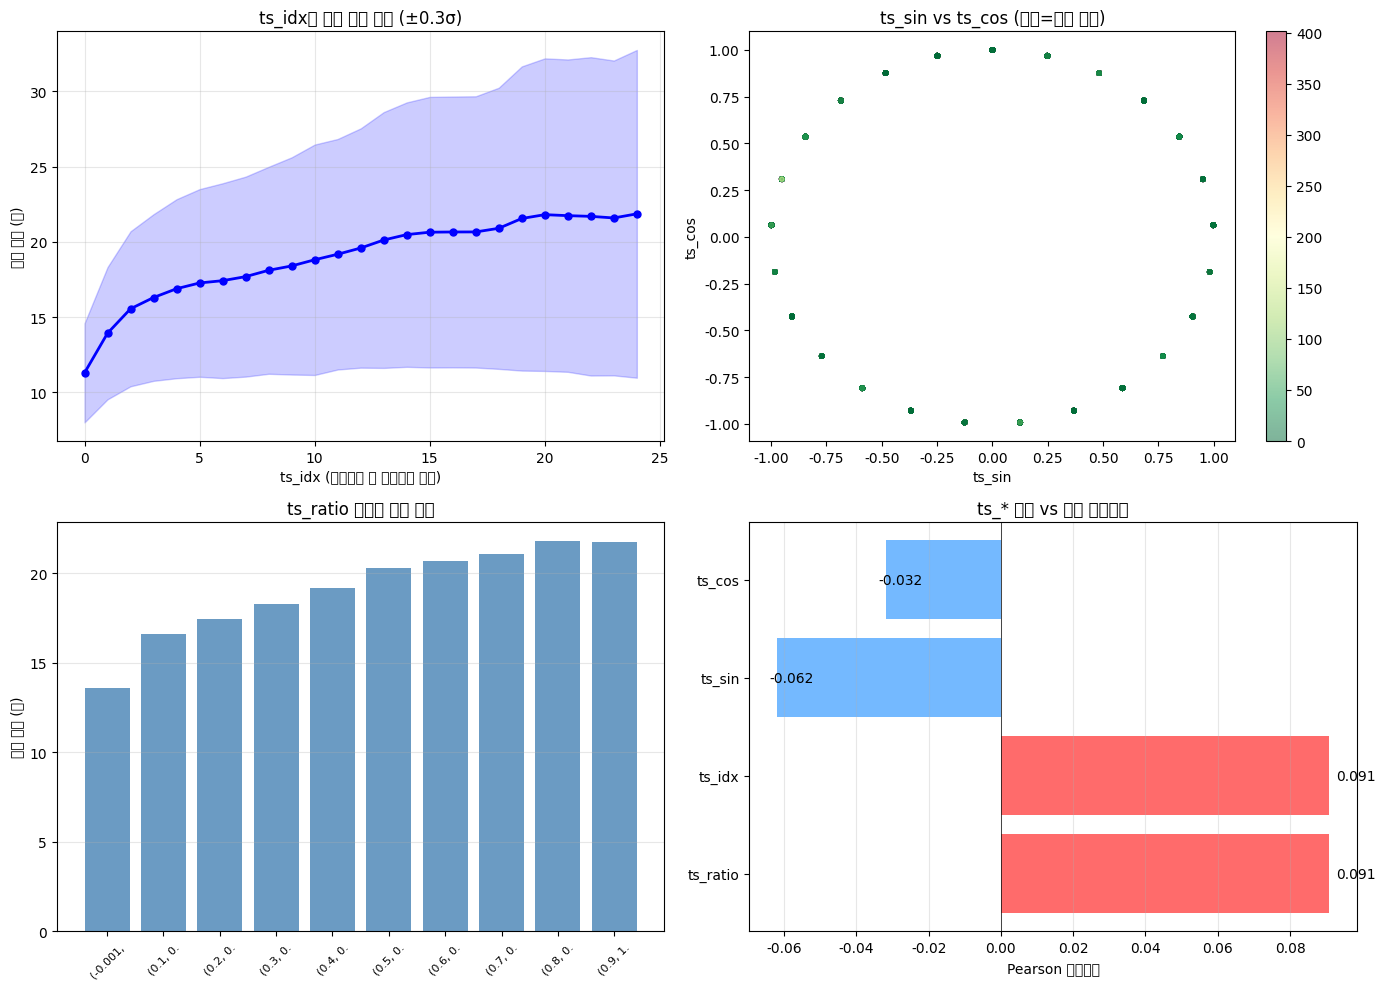

ts_features_analysis.png 저장 완료


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ts_idx vs 평균 지연
ts_mean = train_ts.groupby('ts_idx')[TARGET].mean()
ts_std  = train_ts.groupby('ts_idx')[TARGET].std()
axes[0, 0].plot(ts_mean.index, ts_mean.values, 'b-o', linewidth=2, markersize=5)
axes[0, 0].fill_between(ts_mean.index, ts_mean - ts_std*0.3, ts_mean + ts_std*0.3,
                         alpha=0.2, color='blue')
axes[0, 0].set_title('ts_idx별 평균 출고 지연 (±0.3σ)', fontsize=12)
axes[0, 0].set_xlabel('ts_idx (시나리오 내 타임슬롯 순서)')
axes[0, 0].set_ylabel('평균 지연 (분)')
axes[0, 0].grid(alpha=0.3)

# ts_sin/cos 산점도
sample = np.random.RandomState(42).choice(len(train_ts), 3000, replace=False)
sc = axes[0, 1].scatter(train_ts['ts_sin'].iloc[sample], train_ts['ts_cos'].iloc[sample],
                         c=train_ts[TARGET].iloc[sample], cmap='RdYlGn_r', s=10, alpha=0.5)
plt.colorbar(sc, ax=axes[0, 1])
axes[0, 1].set_title('ts_sin vs ts_cos (색상=지연 시간)', fontsize=12)
axes[0, 1].set_xlabel('ts_sin'); axes[0, 1].set_ylabel('ts_cos')

# ts_ratio vs 타겟 (10구간 평균)
train_ts['ts_bucket'] = pd.cut(train_ts['ts_ratio'], bins=10)
bucket_mean = train_ts.groupby('ts_bucket')[TARGET].mean()
axes[1, 0].bar(range(len(bucket_mean)), bucket_mean.values, color='steelblue', alpha=0.8)
axes[1, 0].set_xticks(range(len(bucket_mean)))
axes[1, 0].set_xticklabels([str(b)[:8] for b in bucket_mean.index], rotation=45, fontsize=8)
axes[1, 0].set_title('ts_ratio 구간별 평균 지연', fontsize=12)
axes[1, 0].set_ylabel('평균 지연 (분)')
axes[1, 0].grid(axis='y', alpha=0.3)

# ts_idx 피처 중요도 미리보기 (타겟과 상관관계)
corr_ts = train_ts[ts_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
colors = ['#FF6B6B' if v > 0 else '#74B9FF' for v in corr_ts.values]
axes[1, 1].barh(corr_ts.index, corr_ts.values, color=colors)
axes[1, 1].set_title('ts_* 피처 vs 타겟 상관관계', fontsize=12)
axes[1, 1].set_xlabel('Pearson 상관계수')
axes[1, 1].axvline(0, color='black', linewidth=0.5)
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(corr_ts.values):
    axes[1, 1].text(v + 0.002 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../docs/ts_features_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('ts_features_analysis.png 저장 완료')


## 5. GroupKFold — 베이스라인 (ts 피처 없음) vs ts 피처 추가

In [5]:
gkf = GroupKFold(n_splits=N_SPLITS)

def run_cv(df_train, df_test, exclude_extra=None, label=''):
    """GroupKFold CV 실행 함수"""
    excl = ['ID', 'layout_id', 'scenario_id', TARGET]
    if exclude_extra:
        excl += exclude_extra
    feat_cols = [c for c in df_train.columns if c not in excl]
    # ts_bucket 컬럼 제거 (카테고리형, 범위 인터벌)
    feat_cols = [c for c in feat_cols if c != 'ts_bucket']
    X = df_train[feat_cols].values
    y = df_train[TARGET].values
    groups = df_train['scenario_id'].values
    X_test_ = df_test[feat_cols].values

    oof = np.zeros(len(df_train))
    test_preds_list = []
    fold_maes = []

    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X[tr_idx], y[tr_idx],
                  eval_set=[(X[val_idx], y[val_idx])],
                  callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
        oof[val_idx] = model.predict(X[val_idx]).clip(min=0)
        test_preds_list.append(model.predict(X_test_).clip(min=0))
        mae = mean_absolute_error(y[val_idx], oof[val_idx])
        fold_maes.append(mae)
        print(f'  [{label}] Fold {fold+1}: MAE={mae:.4f}, iter={model.best_iteration_}')

    oof_mae = mean_absolute_error(y, oof)
    test_pred = np.mean(test_preds_list, axis=0)
    print(f'  [{label}] OOF MAE = {oof_mae:.4f} (std={np.std(fold_maes):.4f})')
    return oof_mae, np.std(fold_maes), oof, test_pred, feat_cols

# 베이스라인 (ts 피처 없음)
print('=== 베이스라인 (ts 피처 없음) ===')
mae_base, std_base, oof_base, test_base, feat_base = run_cv(
    train_ts, test_ts, exclude_extra=['ts_idx', 'ts_ratio', 'ts_sin', 'ts_cos', 'ts_bucket'], label='Base')


=== 베이스라인 (ts 피처 없음) ===


  [Base] Fold 1: MAE=9.1363, iter=630


  [Base] Fold 2: MAE=9.3006, iter=104


  [Base] Fold 3: MAE=8.8462, iter=182


  [Base] Fold 4: MAE=9.6078, iter=704


  [Base] Fold 5: MAE=9.1863, iter=81
  [Base] OOF MAE = 9.2154 (std=0.2468)


In [6]:
# ts 피처 포함
print('=== ts 피처 추가 (ts_idx, ts_ratio, ts_sin, ts_cos) ===')
mae_ts, std_ts, oof_ts, test_ts_pred, feat_ts = run_cv(
    train_ts, test_ts, label='TS')


=== ts 피처 추가 (ts_idx, ts_ratio, ts_sin, ts_cos) ===


  [TS] Fold 1: MAE=9.1028, iter=318


  [TS] Fold 2: MAE=9.2708, iter=154


  [TS] Fold 3: MAE=8.8043, iter=97


  [TS] Fold 4: MAE=9.5541, iter=530


  [TS] Fold 5: MAE=9.1628, iter=88
  [TS] OOF MAE = 9.1790 (std=0.2431)


## 6. 결과 비교 시각화

  베이스라인 (ts 없음) OOF MAE : 9.2154 분
  ts 피처 추가        OOF MAE : 9.1790 분
  개선량                       : +0.0365 분
  개선율                       : +0.40%


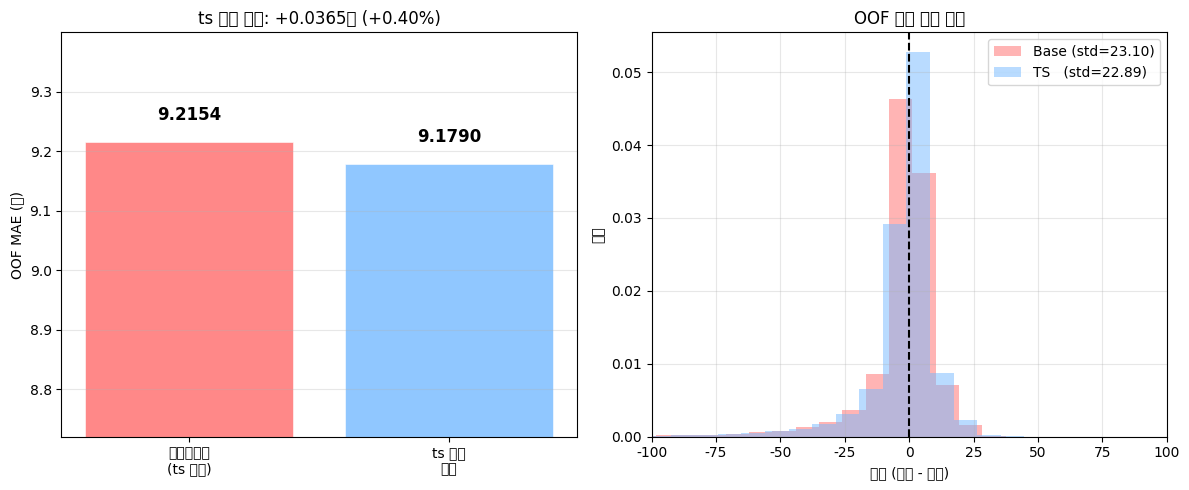

In [7]:
improvement = mae_base - mae_ts
improvement_pct = improvement / mae_base * 100

print('=' * 55)
print(f'  베이스라인 (ts 없음) OOF MAE : {mae_base:.4f} 분')
print(f'  ts 피처 추가        OOF MAE : {mae_ts:.4f} 분')
print(f'  개선량                       : {improvement:+.4f} 분')
print(f'  개선율                       : {improvement_pct:+.2f}%')
print('=' * 55)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories = ['베이스라인\n(ts 없음)', 'ts 피처\n추가']
maes = [mae_base, mae_ts]
colors = ['#FF6B6B', '#74B9FF']
bars = axes[0].bar(categories, maes, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('OOF MAE (분)')
axes[0].set_title(f'ts 피처 효과: {improvement:+.4f}분 ({improvement_pct:+.2f}%)', fontsize=12)
axes[0].set_ylim(min(maes)*0.95, max(maes)*1.02)
axes[0].grid(axis='y', alpha=0.3)

# 잔차 비교
y_all = train_ts[TARGET].values
axes[1].hist(oof_base - y_all, bins=80, alpha=0.5, color='#FF6B6B',
             label=f'Base (std={np.std(oof_base-y_all):.2f})', density=True)
axes[1].hist(oof_ts   - y_all, bins=80, alpha=0.5, color='#74B9FF',
             label=f'TS   (std={np.std(oof_ts-y_all):.2f})', density=True)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlim(-100, 100)
axes[1].set_xlabel('잔차 (예측 - 실제)')
axes[1].set_ylabel('밀도')
axes[1].set_title('OOF 잔차 분포 비교')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/ts_features_effect.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. 피처 중요도 분석

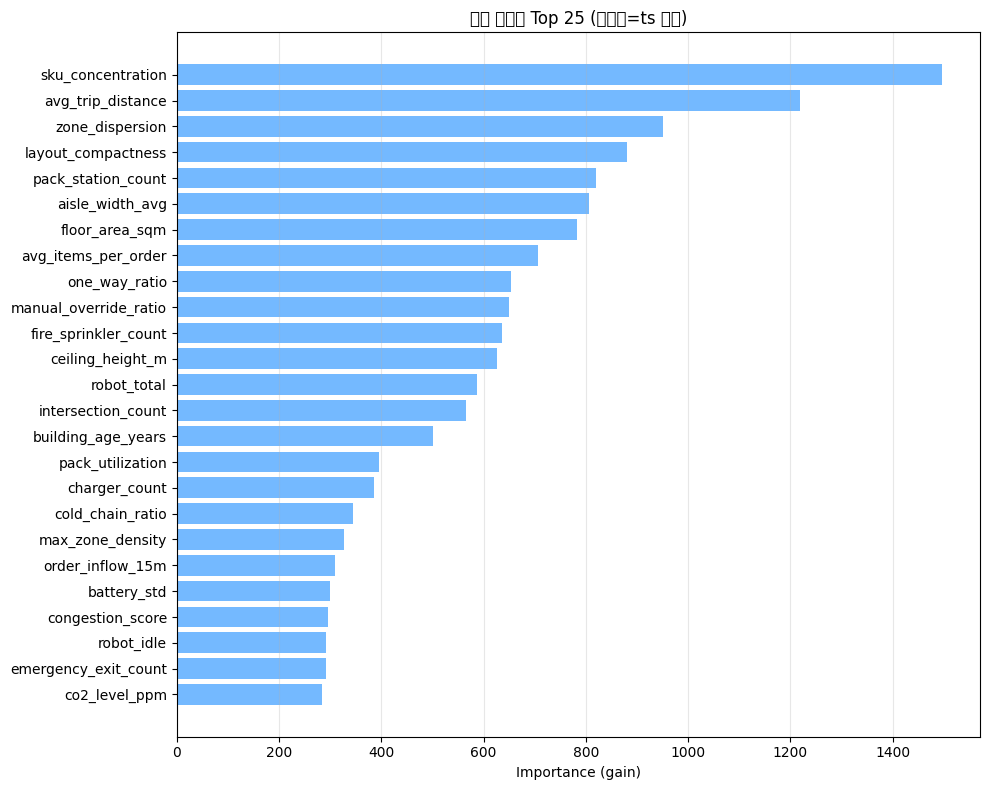


=== ts 피처 중요도 순위 ===
  ts_idx         : 중요도  147.0 (전체 90위/108개)
  ts_ratio       : 중요도   39.0 (전체 101위/108개)
  ts_cos         : 중요도   19.0 (전체 104위/108개)
  ts_sin         : 중요도    9.0 (전체 107위/108개)


In [8]:
# ts 피처 포함 모델의 피처 중요도 확인 (마지막 fold 기준)
# 전체 데이터로 단일 모델 학습 (중요도 시각화용)
X_all  = train_ts[[c for c in feat_ts if c != 'ts_bucket']].values
y_all_ = train_ts[TARGET].values

fi_model = lgb.LGBMRegressor(**{**lgb_params, 'n_estimators': 500, 'early_stopping_rounds': None})
fi_model.fit(X_all, y_all_)

feat_names = [c for c in feat_ts if c != 'ts_bucket']
fi_df = pd.DataFrame({'feature': feat_names, 'importance': fi_model.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=False)

# 상위 25개
top25 = fi_df.head(25)
ts_in_top = top25[top25['feature'].str.startswith('ts_')]

fig, ax = plt.subplots(figsize=(10, 8))
colors_ = ['#FF6B6B' if f.startswith('ts_') else '#74B9FF' for f in top25['feature']]
ax.barh(top25['feature'][::-1], top25['importance'][::-1], color=colors_[::-1])
ax.set_title('피처 중요도 Top 25 (빨간색=ts 피처)', fontsize=12)
ax.set_xlabel('Importance (gain)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/ts_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== ts 피처 중요도 순위 ===')
ts_rank = fi_df.reset_index(drop=True)
ts_rank.index += 1
for _, row in fi_df[fi_df['feature'].str.startswith('ts_')].iterrows():
    rank = fi_df.reset_index(drop=True).index[fi_df['feature'] == row['feature']][0] + 1
    print(f'  {row["feature"]:15s}: 중요도 {row["importance"]:6.1f} (전체 {rank}위/{len(fi_df)}개)')


## 8. 제출 파일 생성 및 결론

In [9]:
# 더 좋은 결과로 제출 파일 생성
submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')
best_preds = test_ts_pred if mae_ts <= mae_base else test_base
best_label = 'ts' if mae_ts <= mae_base else 'base'
submission['avg_delay_minutes_next_30m'] = best_preds.clip(min=0)
out_path = f'../submissions/groupkfold_{best_label}_lgbm.csv'
submission.to_csv(out_path, index=False)

print(f'제출 파일 저장: {out_path}')
print(f'예측 통계: mean={best_preds.mean():.2f}, std={best_preds.std():.2f}, min={best_preds.min():.2f}, max={best_preds.max():.2f}')
print(f'\n✅ 채택 전략: GroupKFold + {best_label} 피처')
print(f'   다음 단계: Week 2 Lag/Rolling/Domain 피처 엔지니어링')


제출 파일 저장: ../submissions/groupkfold_ts_lgbm.csv
예측 통계: mean=17.98, std=12.88, min=0.23, max=42.87

✅ 채택 전략: GroupKFold + ts 피처
   다음 단계: Week 2 Lag/Rolling/Domain 피처 엔지니어링


## 9. 다음 단계

**Week 2 피처 엔지니어링 우선순위** (ts_idx 기반 선행 정렬 후):
1. **Lag 피처** (lag1~3): 이전 타임슬롯 상태 → 현재 지연 예측에 가장 강력
2. **Rolling 피처** (roll3/5 mean+std): 단기 추세 포착
3. **Domain 복합 피처**: battery_crisis, charge_bottleneck, order_pressure 등
